## **Section 1: Import libraries**

In [42]:
#Numerical computing 
import numpy as np 
#Data maipulation 
import pandas as pd
#Plotting 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 
#Statistical Visualization
import seaborn as sns
#Standard ML library 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

In [43]:
# ── DISPLAY SETTINGS ─────────────────────────────────────────────────────────
# Show all columns when printing DataFrames
pd.set_option('display.max_columns', None)
# Set a clean visual style for all charts
sns.set_theme(style='darkgrid', palette='muted')
# Larger default figure size
plt.rcParams['figure.figsize'] = (14, 5)

## **Section 2: Load and Inspect Data (EDA Part1)**

In [44]:
#load data 
df=pd.read_csv('../data/raw/XAUUSD_raw.csv', parse_dates=['Date'], index_col='Date')
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2022-01-03,1802.51,1821.41,1796.03,1803.97,93230.0
2022-01-04,1802.76,1804.05,1794.52,1803.47,109009.0
2022-01-05,1810.69,1825.77,1797.24,1809.25,150969.0
2022-01-06,1817.17,1824.61,1811.72,1822.04,113866.0
2022-01-07,1819.71,1827.47,1802.38,1820.76,185400.0


In [45]:
print(df.tail())

               Open     High      Low    Close    Volume
Date                                                    
2023-11-27  2151.03  2160.04  2136.32  2152.84   98693.0
2023-11-28  2143.95  2146.89  2143.13  2145.14  159674.0
2023-11-29  2141.69  2162.96  2139.42  2144.22  195598.0
2023-11-30  2141.23  2148.89  2134.97  2137.81  199028.0
2023-12-01  2123.54  2133.46  2120.39  2127.35  133161.0


In [46]:
#Shape 
rows, cols=df.shape
print(f'Dataset has: {rows} rows (trading days)and {cols} columns (features)')

Dataset has: 500 rows (trading days)and 5 columns (features)


In [47]:
#Features Datatypes 
print (df.dtypes)

Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object


In [48]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print('---MISSING VALUES REPORT---')
print(missing_report)
missing_report

---MISSING VALUES REPORT---
        Missing Count  Missing %
Open                0        0.0
High                0        0.0
Low                 0        0.0
Close               5        1.0
Volume             10        2.0


,Missing Count,Missing %
Open,0,0.0
High,0,0.0
Low,0,0.0
Close,5,1.0
Volume,10,2.0


In [49]:
#Copy the dataset to maintain raw one
dfc=df.copy()
dfc

,Open,High,Low,Close,Volume
Date,,,,,
2022-01-03,1802.51,1821.41,1796.03,1803.97,93230.0
2022-01-04,1802.76,1804.05,1794.52,1803.47,109009.0
2022-01-05,1810.69,1825.77,1797.24,1809.25,150969.0
2022-01-06,1817.17,1824.61,1811.72,1822.04,113866.0
2022-01-07,1819.71,1827.47,1802.38,1820.76,185400.0
...,...,...,...,...,...
2023-11-27,2151.03,2160.04,2136.32,2152.84,98693.0
2023-11-28,2143.95,2146.89,2143.13,2145.14,159674.0
2023-11-29,2141.69,2162.96,2139.42,2144.22,195598.0


In [55]:
#Filling missing Close values using linear interpolation
dfc['Close']=dfc['Close'].interpolate(method='linear')
#Filling missing volumes using rollling mean
dfc['Volume']=dfc['Volume'].fillna(dfc['Volume'].rolling(5).mean())
dfc['Volume']=dfc['Volume'].fillna(0)

In [56]:
dfc.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [57]:
print(dfc.describe().round(2))

          Open     High      Low    Close     Volume
count   500.00   500.00   500.00   500.00     500.00
mean   1939.01  1949.01  1928.98  1938.97  137535.19
std     135.40   135.56   135.46   135.50   38948.97
min    1732.57  1742.92  1726.98  1735.17       0.00
25%    1798.32  1810.96  1791.67  1797.25  109428.25
50%    1936.48  1946.36  1925.76  1935.51  140203.00
75%    2069.24  2077.00  2058.17  2070.09  166735.75
max    2181.27  2196.30  2180.29  2182.40  199664.00


### **Section  3: EDA Part2**

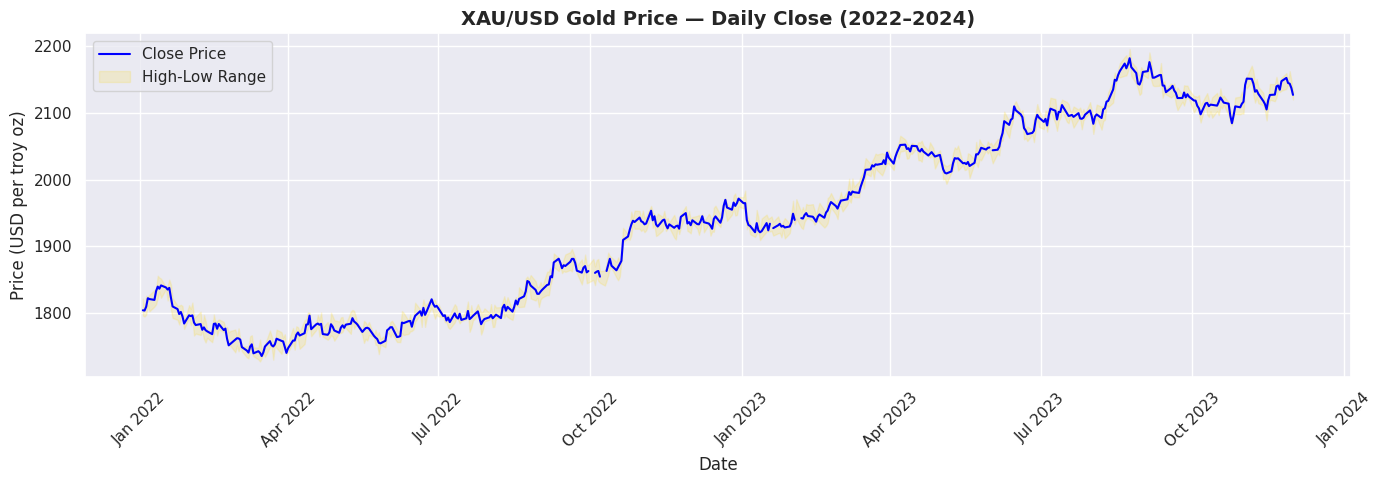

In [58]:
#Chart 1: Price over time - time series plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['Close'], color='blue', linewidth=1.5, label='Close Price')
ax.fill_between(df.index, df['Low'], df['High'], alpha=0.15, color='gold', label='High-Low Range')

ax.set_title('XAU/USD Gold Price — Daily Close (2022–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD per troy oz)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


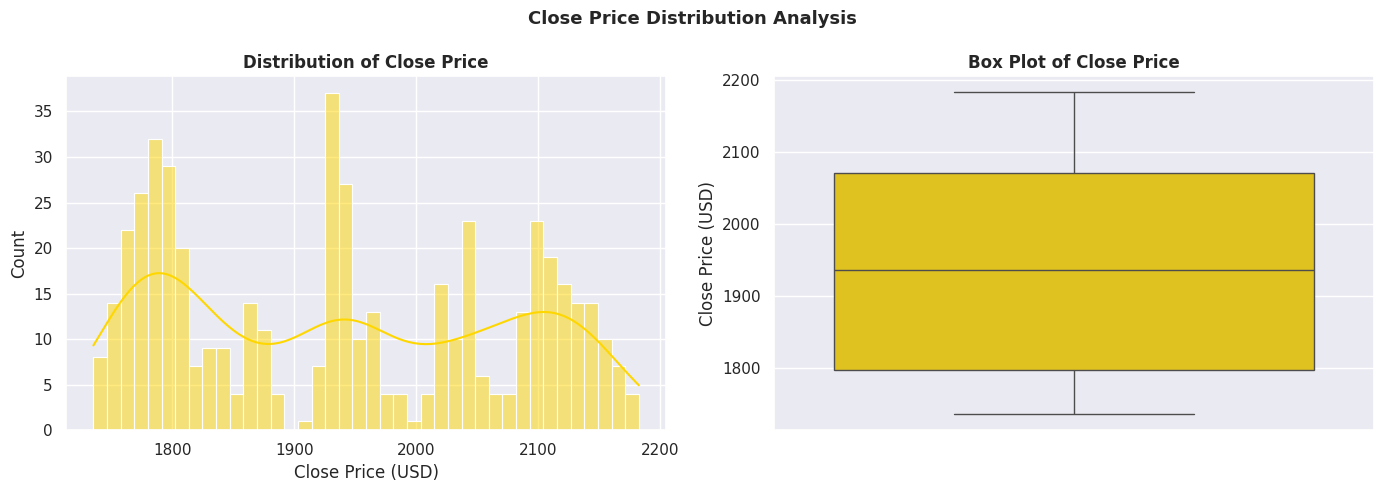

📌 Box plot legend:
   Line in box = median (50th percentile)
   Box edges   = 25th and 75th percentile (the "middle 50%" of data)
   Whiskers    = acceptable range
   Dots        = outliers (values unusually far from the rest)


In [59]:
#Chart 2:Distribution of close price 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(dfc['Close'].dropna(), kde=True, bins=40, color='gold', ax=axes[0])
axes[0].set_title('Distribution of Close Price', fontweight='bold')
axes[0].set_xlabel('Close Price (USD)')

# Box plot — shows median, quartiles, and outliers at a glance
sns.boxplot(y=dfc['Close'].dropna(), color='gold', ax=axes[1])
axes[1].set_title('Box Plot of Close Price', fontweight='bold')
axes[1].set_ylabel('Close Price (USD)')

plt.suptitle('Close Price Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Box plot legend:')
print('   Line in box = median (50th percentile)')
print('   Box edges   = 25th and 75th percentile (the "middle 50%" of data)')
print('   Whiskers    = acceptable range')
print('   Dots        = outliers (values unusually far from the rest)')

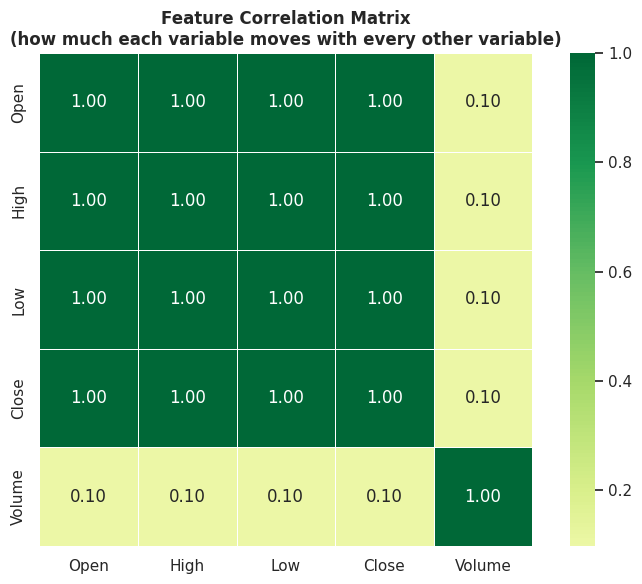

📌 Key insight: Open, High, and Low are highly correlated with Close.
   This makes sense — they are all prices for the same day!
   Volume has a lower correlation — price and trading activity are loosely linked.


In [60]:
#Correlation Heatmap
corr_matrix = dfc.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,           # show the numbers inside each cell
    fmt='.2f',            # round to 2 decimal places
    cmap='RdYlGn',        # Red = negative, Yellow = neutral, Green = positive
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlation Matrix\n(how much each variable moves with every other variable)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Key insight: Open, High, and Low are highly correlated with Close.')
print('   This makes sense — they are all prices for the same day!')
print('   Volume has a lower correlation — price and trading activity are loosely linked.')

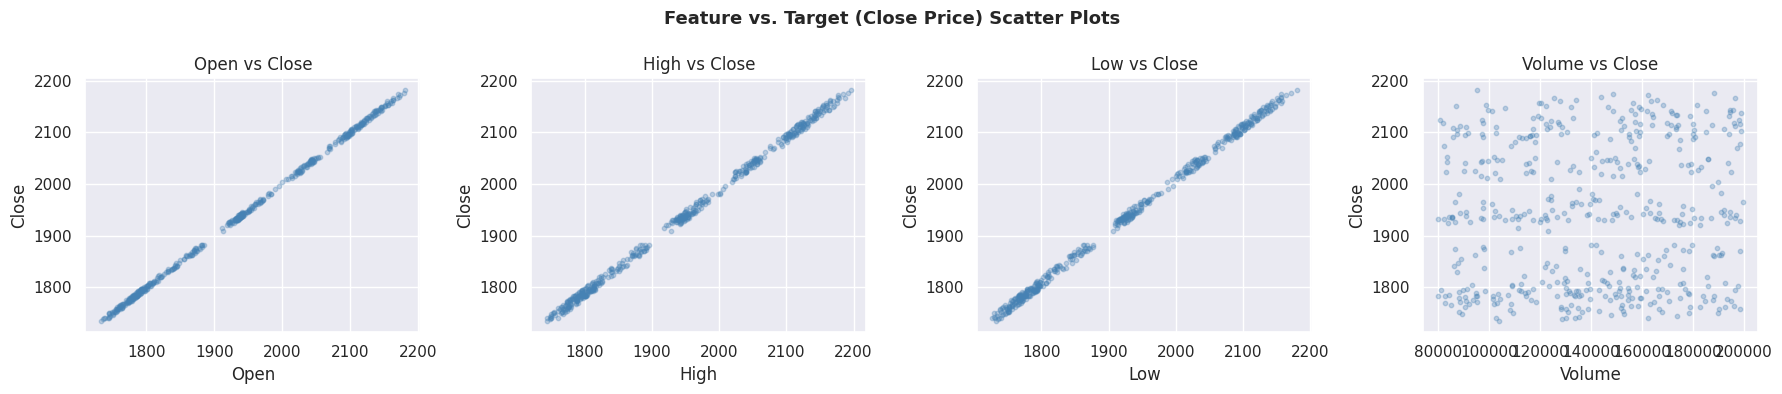

📌 Open, High, Low show tight linear relationships with Close → great features!
   Volume is scattered → weaker predictor on its own.


In [61]:
#Chart 4: Scatter Plots
features = ['Open', 'High', 'Low', 'Volume']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['Close'], alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Close')
    axes[i].set_title(f'{feat} vs Close')

plt.suptitle('Feature vs. Target (Close Price) Scatter Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Open, High, Low show tight linear relationships with Close → great features!')
print('   Volume is scattered → weaker predictor on its own.')

## **Section 4: Feature engineering**

### We create the following features:
#### 1.Daily Range:  High - Low (measures daily volatility)
#### 2.Moving Averages: average price over last N days (smooths out noise)
#### 3.Moving Averages: average price over last N days (smooths out noise)
#### 4.Lag features: yesterday's Close (give the model memory)
#### 5.Gap: today's open - yestarday's close

In [63]:
dfc

,Open,High,Low,Close,Volume
Date,,,,,
2022-01-03,1802.51,1821.41,1796.03,1803.97,93230.0
2022-01-04,1802.76,1804.05,1794.52,1803.47,109009.0
2022-01-05,1810.69,1825.77,1797.24,1809.25,150969.0
2022-01-06,1817.17,1824.61,1811.72,1822.04,113866.0
2022-01-07,1819.71,1827.47,1802.38,1820.76,185400.0
...,...,...,...,...,...
2023-11-27,2151.03,2160.04,2136.32,2152.84,98693.0
2023-11-28,2143.95,2146.89,2143.13,2145.14,159674.0
2023-11-29,2141.69,2162.96,2139.42,2144.22,195598.0


In [75]:
dfd=dfc.copy()

In [76]:
dfd['Daily_Range']=dfc['High']-dfc['Low']

In [77]:
#dfd['Gap']=dfc['Close']-dfc['Open']

In [78]:
dfd['MA_5']=dfd['Close'].rolling(window=5).mean()
dfd['MA_20']=dfd['Close'].rolling(window=20).mean()

In [79]:
dfd['Prev_Close'] = dfd['Close'].shift(1)

In [80]:

# Drop NaN rows created by rolling and shift operations
dfd= dfd.dropna()

print('New features added:')
print(dfd[['Close', 'Daily_Range', 'MA_5', 'MA_20', 'Prev_Close']].head(8).round(2))

New features added:
              Close  Daily_Range     MA_5    MA_20  Prev_Close
Date                                                          
2022-01-28  1784.02        10.19  1796.83  1817.81     1794.71
2022-01-31  1796.34        18.69  1794.94  1817.42     1784.02
2022-02-01  1795.14        24.72  1794.32  1817.01     1796.34
2022-02-02  1796.28        26.18  1793.30  1816.36     1795.14
2022-02-03  1785.48        26.35  1791.45  1814.53     1796.28
2022-02-04  1781.73        25.47  1790.99  1812.58     1785.48
2022-02-07  1783.22        35.09  1788.37  1810.77     1781.73
2022-02-08  1774.61         4.70  1784.26  1807.86     1783.22


In [81]:
dfd

,Open,High,Low,Close,Volume,Daily_Range,MA_5,MA_20,Prev_Close
Date,,,,,,,,,
2022-01-28,1785.04,1786.15,1775.96,1784.02,107516.0,10.19,1796.826,1817.8065,1794.71
2022-01-31,1791.65,1811.56,1792.87,1796.34,167969.0,18.69,1794.942,1817.4250,1784.02
2022-02-01,1791.48,1805.96,1781.24,1795.14,81089.0,24.72,1794.318,1817.0085,1796.34
2022-02-02,1793.11,1815.54,1789.36,1796.28,117346.0,26.18,1793.298,1816.3600,1795.14
2022-02-03,1787.90,1792.32,1765.97,1785.48,154663.0,26.35,1791.452,1814.5320,1796.28
...,...,...,...,...,...,...,...,...,...
2023-11-27,2151.03,2160.04,2136.32,2152.84,98693.0,23.72,2143.508,2132.2615,2147.92
2023-11-28,2143.95,2146.89,2143.13,2145.14,159674.0,3.76,2144.494,2133.8220,2152.84
2023-11-29,2141.69,2162.96,2139.42,2144.22,195598.0,23.54,2145.052,2135.1820,2145.14


In [84]:
dfd.describe()

,Open,High,Low,Close,Volume,Daily_Range,MA_5,MA_20,Prev_Close
count,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000
mean,1943.692245,1953.711684,1933.779023,1943.681143,137623.257796,19.932661,1942.279418,1937.408970,1942.989584
std,135.902041,136.061814,135.870363,135.986035,39340.466278,8.308161,135.556128,133.559446,135.895831
min,1732.570000,1742.920000,1726.980000,1735.170000,0.000000,2.000000,1739.508000,1747.830000,1735.170000
25%,1795.720000,1809.580000,1789.910000,1796.340000,109165.000000,14.130000,1794.830000,1798.140500,1796.280000
50%,1939.090000,1949.050000,1928.130000,1938.970000,140348.000000,19.740000,1937.648000,1936.041500,1938.410000
75%,2077.630000,2091.710000,2067.960000,2081.380000,167969.000000,26.000000,2078.380000,2060.780000,2077.530000
max,2181.270000,2196.300000,2180.290000,2182.400000,199664.000000,39.120000,2173.252000,2160.962500,2182.400000


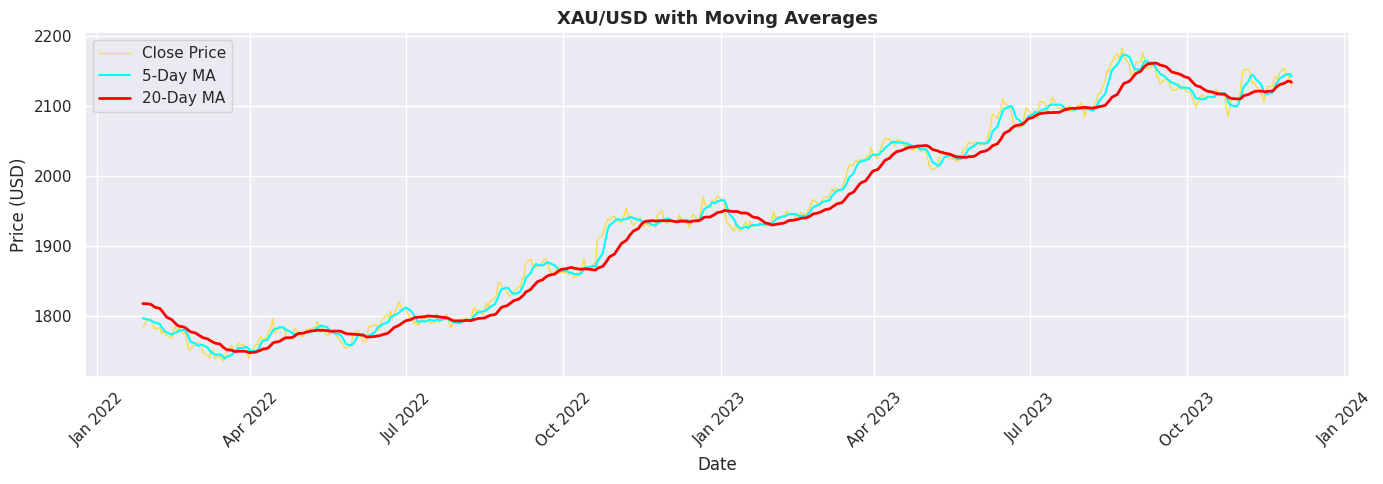

📌 The 20-day MA (red) is smoother — it filters out day-to-day noise.
   Traders use MA crossovers as buy/sell signals (relevant for Phase 3!).


In [86]:
#Visualizing moving averages
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dfd.index, dfd['Close'], color='gold', linewidth=1, alpha=0.7, label='Close Price')
ax.plot(dfd.index, dfd['MA_5'],  color='cyan',  linewidth=1.5, label='5-Day MA')
ax.plot(dfd.index, dfd['MA_20'], color='red',   linewidth=2,   label='20-Day MA')

ax.set_title('XAU/USD with Moving Averages', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('📌 The 20-day MA (red) is smoother — it filters out day-to-day noise.')
print('   Traders use MA crossovers as buy/sell signals (relevant for Phase 3!).')

## **Section 6:Feature Definition and Train/Test splitting**